# Numero di accordi che si possono fare al pianoforte

In [2]:
# piramide numerica
import numpy as np
import gmpy2

ty = object  # IMPORTANT: allows mpz in NumPy arrays

def genera_piramide(n):
    # start with mpz(1)
    piramide = [
        np.array([gmpy2.mpz(1)], dtype=ty), # 1
        np.array([gmpy2.mpz(1), gmpy2.mpz(1)], dtype=ty)] # 1 1

    for i in range(1, n):
        prev = piramide[i]
        
        middle = [prev[j] + prev[j+1] for j in range(len(prev)-1)]
        
        row = np.array([gmpy2.mpz(1)] + middle + [gmpy2.mpz(1)],dtype=ty)

        piramide.append(row)
        
    return piramide


p = genera_piramide(88)

# print(p[-1])            # print piramide
print('Numero di accordi che si possono fare al pianoforte:',np.sum(p[-1])-1)     # print somma riga

Numero di accordi che si possono fare al pianoforte: 309485009821345068724781055


# piccolo teorema fermat


Sia $p$ primo e $a \in Z$ con $p$ che non divide $a$. Allora $a^{p-1} = 1mod p$

In [3]:
prime = np.array([x for x in range(1000) if gmpy2.is_prime(x)], dtype=ty)

for a in range(2,np.max(prime)*2):
    for p in prime:
        if type(a / p) == int:
            if a**(p-1) % p != 1:
                print(f"Fermat fallisce per a={a}, p={p}")
                break

print("Fermat tiene per tutti i casi testati")

Fermat tiene per tutti i casi testati


# tavole di composizione modulo N:

In [4]:
mod = 4

# tavole di composizione modulo N:

classes = np.array([i for i in range(mod)])
table_prod = np.outer(classes,classes.T) % mod
table_sum = np.array([[i+j for j in classes] for i in classes]) % mod
print(table_prod)
print(table_sum)

[[0 0 0 0]
 [0 1 2 3]
 [0 2 0 2]
 [0 3 2 1]]
[[0 1 2 3]
 [1 2 3 0]
 [2 3 0 1]
 [3 0 1 2]]


# Algoritmo euclideo

In [5]:
a = 107432895
b = 457445

r = {'i':a,'i+1':b}

while r['i+1'] != 0:
    r_next = r['i'] % r['i+1']
    r['i'] = r['i+1']
    r['i+1'] = r_next

print('MCD: ', r['i'])

MCD:  5


# IDENTITà di Bezout:

MCD(a,b) = au+bv

In [6]:
# obiettivo: trovare u,v t.c. MCD(a,b) = au + bv


# prova ottima con 110 42
a = gmpy2.mpz(110575433489)
b = gmpy2.mpz(4264)

r = {'i':a,'i+1':b}

quozienti = []
resti = [a,b]
dividendi = []
while r['i+1'] != 0:
    r_next = r['i'] % r['i+1']
    q = r['i'] // r['i+1']
    quozienti.append(q)
    resti.append(r_next)
    dividendi.append(r['i'])
    r['i'] = r['i+1']
    r['i+1'] = r_next

MCD = resti[-2]

# calcolo dei coefficienti:

n = len(quozienti) #dividendo7 = 2 e non è contenuto nell'array

xy = (dividendi[n-2],dividendi[n-1])
coeff = (1,-quozienti[n-2])

for i in range(n-3,-1,-1):
    print(f'{MCD}={coeff[0]}[{xy[0]}]{'+' if coeff[1]>0 else ''}{coeff[1]}[{xy[1]}]')
    coeff = (coeff[1],coeff[0]-quozienti[i]*coeff[1])
    xy = (dividendi[i],dividendi[i+1])
print(f'{MCD}={coeff[0]}[{xy[0]}]{'+' if coeff[1]>0 else ''}{coeff[1]}[{xy[1]}]')

if MCD != coeff[0]*xy[0] + coeff[1]*xy[1]:
    raise('Error in calculation')


1=1[41]-5[8]
1=-5[90]+11[41]
1=11[221]-27[90]
1=-27[311]+38[221]
1=38[3953]-483[311]
1=-483[4264]+521[3953]
1=521[110575433489]-13510741287[4264]


complessità algoritmo:

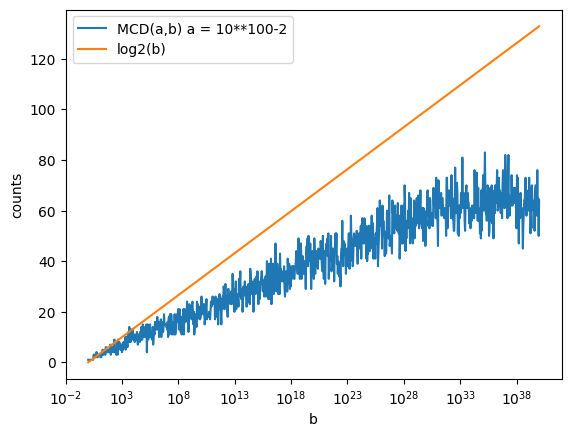

101


In [44]:
a = gmpy2.mpz(110)
b = gmpy2.mpz(42)


def gcd_counter(a,b):
    counter = 0

    while b!=0:
        r = a % b
        a,b = b,r
        counter += 1

    return counter

N = np.logspace(0,40,1000)
A = gmpy2.mpz(10**100-2)
counts = np.array([gcd_counter(A,gmpy2.mpz(n)) for n in N])


from matplotlib import pyplot as plt
plt.plot(N,counts,label=f'MCD(a,b) a = 10**100-2')
plt.plot(N,np.log2(N),label='log2(b)')
plt.xscale('log')
plt.xlabel('b')
plt.ylabel('counts')
plt.legend()
plt.show()

print(A.num_digits())

# ALGORITMO EUCLIDE ESTESO

In [8]:
# test 110,42

a = gmpy2.mpz(115430)
b = gmpy2.mpz(4421)

u_1 = v0 = gmpy2.mpz(1)
u0 = v_1 = gmpy2.mpz(0)

ab = np.array([a,b])
coeff = np.array([[u_1,v_1],[u0,v0]])

print(f'({ab[0]},{ab[1]}): {ab[1]} = {coeff[1,0]}[{a}]{'+' if coeff[1,1]>=0 else ''}{coeff[1,1]}[{b}]')
while ab[1] != 0:
    m = np.array([[0,1],[1,-(ab[0]//ab[1])]])
    coeff = np.matmul(m,coeff)
    ab = np.matmul(coeff,np.array([a,b]))
    print(f'({ab[0]},{ab[1]}): {ab[1]} = {coeff[1,0]}[{a}]{'+' if coeff[1,1]>=0 else ''}{coeff[1,1]}[{b}]')

    if ab[1] != coeff[1,0]*a + coeff[1,1]*b:
        raise('wrong coefficient!!')


(115430,4421): 4421 = 0[115430]+1[4421]
(4421,484): 484 = 1[115430]-26[4421]
(484,65): 65 = -9[115430]+235[4421]
(65,29): 29 = 64[115430]-1671[4421]
(29,7): 7 = -137[115430]+3577[4421]
(7,1): 1 = 612[115430]-15979[4421]
(1,0): 0 = -4421[115430]+115430[4421]


In [9]:
def extended_GCD(a,b):
    u_1 = v0 = 1
    u0 = v_1 = 0

    ab = np.array([a,b])
    coeff = np.array([[u_1,v_1],[u0,v0]])

    while ab[1] != 0:
        m = np.array([[0,1],[1,-(ab[0]//ab[1])]])
        coeff = np.matmul(m,coeff)
        ab = np.matmul(coeff,np.array([a,b]))
        #print(f'({ab[0]},{ab[1]}): {ab[1]} = {coeff[1,0]}[{a}]{'+' if coeff[1,1]>=0 else ''}{coeff[1,1]}[{b}]')

        if ab[1] != coeff[1,0]*a + coeff[1,1]*b:
            raise('wrong coefficient!!')
        
    return ab[0], (coeff[0,0],coeff[0,1])

def gcd(a,b):
    while b!=0:
        r = a % b
        a,b = b,r
    return a

print(extended_GCD(110,42))
print(gcd(110,55))

(np.int64(2), (np.int64(-8), np.int64(21)))
55


# identità

$M_b = 2^b-1$

$2^{bq} \equiv 1$ (mod $M_b$)

In [10]:
b = 3
q = 3

print(bin(gmpy2.mpz(2**(b*q)-1)))

exponents = np.array([i for i in range(q)])*b
k = np.sum(2**exponents)
print(bin(k))
print(bin((2**b - 1)*k))

0b111111111
0b1001001
0b111111111


esercizi vari

In [11]:
# contatore di cicli:

Fn = Fn1 = 1

iter = 0
stop = 100

while iter != stop:
    iter += 1
    a = gmpy2.mpz(Fn1)
    b = gmpy2.mpz(Fn)

    u_1 = v0 = gmpy2.mpz(1)
    u0 = v_1 = gmpy2.mpz(0)

    ab = np.array([a,b])
    coeff = np.array([[u_1,v_1],[u0,v0]])

    counter = 0
    # print(f'({ab[0]},{ab[1]}): {ab[1]} = {coeff[1,0]}[{a}]{'+' if coeff[1,1]>=0 else ''}{coeff[1,1]}[{b}]')
    while ab[1] != 0:
        counter += 1
        m = np.array([[0,1],[1,-(ab[0]//ab[1])]])
        coeff = np.matmul(m,coeff)
        ab = np.matmul(coeff,np.array([a,b]))
        # print(f'({ab[0]},{ab[1]}): {ab[1]} = {coeff[1,0]}[{a}]{'+' if coeff[1,1]>=0 else ''}{coeff[1,1]}[{b}]')

        if ab[1] != coeff[1,0]*a + coeff[1,1]*b:
            raise('wrong coefficient!!')
        
    print(f'({Fn1},{Fn}): N={counter}')
    Fn1, Fn = Fn1 + Fn, Fn1


(1,1): N=1
(2,1): N=1
(3,2): N=2
(5,3): N=3
(8,5): N=4
(13,8): N=5
(21,13): N=6
(34,21): N=7
(55,34): N=8
(89,55): N=9
(144,89): N=10
(233,144): N=11
(377,233): N=12
(610,377): N=13
(987,610): N=14
(1597,987): N=15
(2584,1597): N=16
(4181,2584): N=17
(6765,4181): N=18
(10946,6765): N=19
(17711,10946): N=20
(28657,17711): N=21
(46368,28657): N=22
(75025,46368): N=23
(121393,75025): N=24
(196418,121393): N=25
(317811,196418): N=26
(514229,317811): N=27
(832040,514229): N=28
(1346269,832040): N=29
(2178309,1346269): N=30
(3524578,2178309): N=31
(5702887,3524578): N=32
(9227465,5702887): N=33
(14930352,9227465): N=34
(24157817,14930352): N=35
(39088169,24157817): N=36
(63245986,39088169): N=37
(102334155,63245986): N=38
(165580141,102334155): N=39
(267914296,165580141): N=40
(433494437,267914296): N=41
(701408733,433494437): N=42
(1134903170,701408733): N=43
(1836311903,1134903170): N=44
(2971215073,1836311903): N=45
(4807526976,2971215073): N=46
(7778742049,4807526976): N=47
(12586269025,

# Congruenze lineari


## TEOREMA 

sia $ax \equiv b$ (mod n) una conguenza lineare modulo $n$, $d = MCD(a,n)$, allora:

1. la conguruenza ammette soluzione sse d | b
2. data una soluzione particolare $c$ le soluzioni sono tutti e soli gli interi $c + k\cdot (n/d)$
3. Se la congruenza ammette soluzioni ha esattamente $d$ soluzioni a due a due non congrue modulo $n$

In [ ]:
# risoluzione congruenza

def solve_congruenza_lin(a,b,n): # a*x - k*n = b => a1*x - k*n1 = b1
    d = gcd(a,n)
    if b%d != 0:
        return None, None
    a1,b1,n1 = a/d, b/d, n/d # MCD(a1,n1) = 1
    _, (u,v) = extended_GCD(a1,n1) # a1*u + n1*v = 1 => a1*(b1*u) + n1*(b1*v) = b1
    x = b1*u
    k = -v*b1
    return x,k

a,b,n = 2,6,7
x,k = solve_congruenza_lin(a,b,n) # ax = b (mod n)
print(f'x={x} k={k}')

if ((a*x - b != k*n) or ((a*x)%n != b%n)) and (x is not None):
    raise(Exception('result error'))


x=-18.0 k=-6.0


In [ ]:
# verifica punto 2.

n = 7

a = 17
b = 47

n1 = n/gcd(a,n)
x,_ = solve_congruenza_lin(a,b,n)

x = x + 5433 * n1
print(x*a % n)

5.0


In [22]:
# estrazione di tutte le soluzioni a due a due non congrue modulo N (3.)
n = 12
a = 21
b = 30
d = gcd(a,n)
n1 = n/d
x,_ = solve_congruenza_lin(a,b,n)
soluzioni = np.array([x + k*n1 for k in range(0,d)],dtype=int)
print('c: ',soluzioni)
print('c%n: ',soluzioni%n)

c:  [-10  -6  -2]
c%n:  [ 2  6 10]


# ELEMENTI INVERTIBILI DI $\mathbb{Z}/n$

gli elementi invertibili sono quelli t.c. 0<x<n sono coprimi con n ossia MCD(x,n) = 1

In [75]:
n = 12
set = np.arange(0,n) # elements in Z/n
print(set)

coprime = np.array([a for a in set if gcd(a,n)==1])
print(coprime)

table = np.outer(set,set) % n

print(table)
print(np.where(table==1))

[ 0  1  2  3  4  5  6  7  8  9 10 11]
[ 1  5  7 11]
[[ 0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  2  4  6  8 10  0  2  4  6  8 10]
 [ 0  3  6  9  0  3  6  9  0  3  6  9]
 [ 0  4  8  0  4  8  0  4  8  0  4  8]
 [ 0  5 10  3  8  1  6 11  4  9  2  7]
 [ 0  6  0  6  0  6  0  6  0  6  0  6]
 [ 0  7  2  9  4 11  6  1  8  3 10  5]
 [ 0  8  4  0  8  4  0  8  4  0  8  4]
 [ 0  9  6  3  0  9  6  3  0  9  6  3]
 [ 0 10  8  6  4  2  0 10  8  6  4  2]
 [ 0 11 10  9  8  7  6  5  4  3  2  1]]
(array([ 1,  5,  7, 11]), array([ 1,  5,  7, 11]))


In [114]:
# Noto che in alcune tabelle gli inversi cadono solo sulla diagonale
# questo è banale nel caso in cui n sia primo

def N_coprimes(n):
    counter = 0
    for i in range(1,n):
        if gcd(i,n) == 1:
            counter += 1
    return counter

# print('coprime', N_coprimes(10))

N = 100
base_set = np.arange(0,N)
for i in range(2,N):
    set = base_set[:i]
    # table = np.outer(set,set)%i
    square = (set*set)%i
    #print(i,': ',square,set[set == 1])
    count_ones_square = np.sum(square == 1)
    count_coprime = N_coprimes(i)
    # print(count_ones_square,count_coprime)
    if count_coprime == count_ones_square:
        print(f'{i}:',[z for z in range(0,i) if gcd(z,i)==1])
        # print(np.diag(table))

2: [1]
3: [1, 2]
4: [1, 3]
6: [1, 5]
8: [1, 3, 5, 7]
12: [1, 5, 7, 11]
24: [1, 5, 7, 11, 13, 17, 19, 23]
